# Financial Risk Assessment for Loan Approval

Prabhath Vinay Viparthi (pv342)
Aravind Chowdary Kamani (ack36)
Mahesh Bodepudi (mb2327)
Nagaraj Vodapalli (nv383)

# Data Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/Loan.csv")
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [ ]:
df.isnull().sum()/len(df)*100

,0
ApplicationDate,0.0
Age,0.0
AnnualIncome,0.0
CreditScore,0.0
EmploymentStatus,0.0
EducationLevel,0.0
Experience,0.0
LoanAmount,0.0
LoanDuration,0.0
MaritalStatus,0.0


In [ ]:
df.duplicated().sum()

0

## Data Exploration

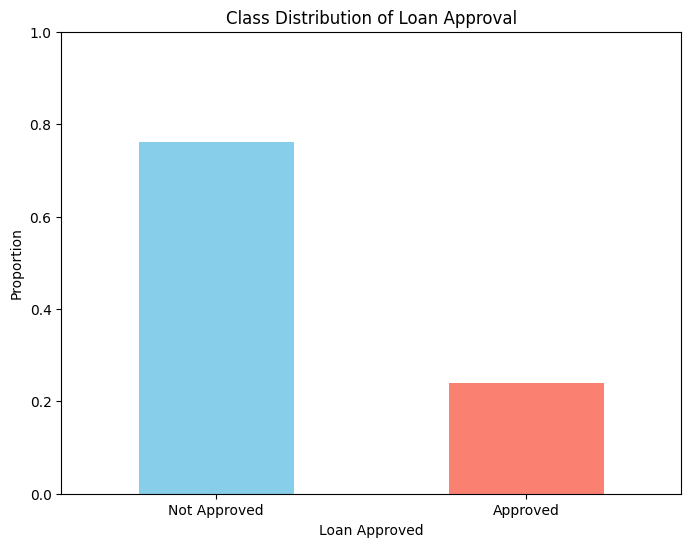

In [31]:
loan_approved_counts = df['LoanApproved'].value_counts(normalize=True)
plt.figure(figsize=(8, 6))
loan_approved_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution of Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Proportion')
plt.xticks(ticks=[0, 1], labels=['Not Approved', 'Approved'], rotation=0)
plt.ylim(0, 1)
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
columns_of_interest = ['MonthlyIncome', 'AnnualIncome', 'NetWorth',
                      'RiskScore', 'TotalDebtToIncomeRatio', 'LoanApproved']

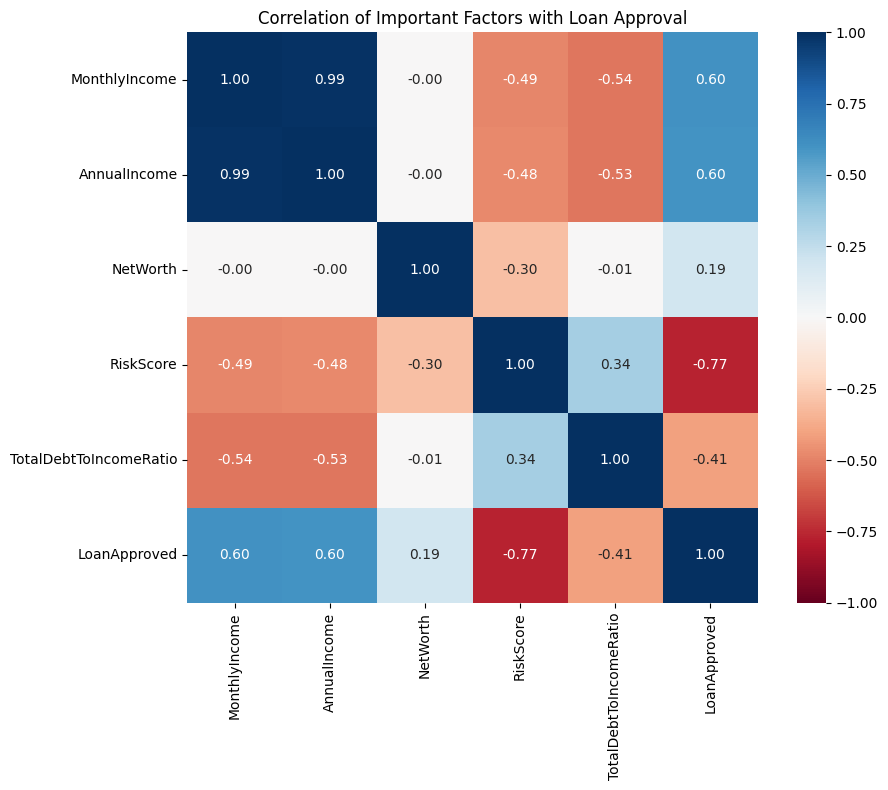

In [ ]:
correlation_matrix = df[columns_of_interest].corr()

# Create a figure with a larger size
plt.figure(figsize=(10, 8))

# Create heatmap using seaborn
sns.heatmap(correlation_matrix,
            annot=True,  # Show correlation values
            cmap='RdBu',  # Red-Blue colormap
            vmin=-1,  # Minimum correlation value
            vmax=1,   # Maximum correlation value
            center=0, # Center the colormap at 0
            fmt='.2f',# Format numbers to 2 decimal places
            square=True)

# Set the title
plt.title('Correlation of Important Factors with Loan Approval')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

# Data Preprocessing

In [ ]:
X=df.drop('LoanApproved',axis=1)
y=df[['LoanApproved']]

In [ ]:
# Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for cols in X.select_dtypes('object').columns:
    X[cols]=le.fit_transform(X[cols])

In [ ]:
#Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter

# Ensure `y` is a Series
y = df['LoanApproved']

# If `y` is not numeric, encode it
if y.dtype == 'object' or not pd.api.types.is_numeric_dtype(y):
    y = LabelEncoder().fit_transform(y)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Check class distribution before SMOTE
print("Class distribution before SMOTE:")
print(Counter(y_train))

# Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
print("\nClass distribution after SMOTE:")
print(Counter(y_train_resampled))

Class distribution before SMOTE:
Counter({0: 12176, 1: 3824})

Class distribution after SMOTE:
Counter({0: 12176, 1: 12176})


# Exploratory Data Analysis

In [ ]:
# Set the style for the plots
sns.set(style="whitegrid")

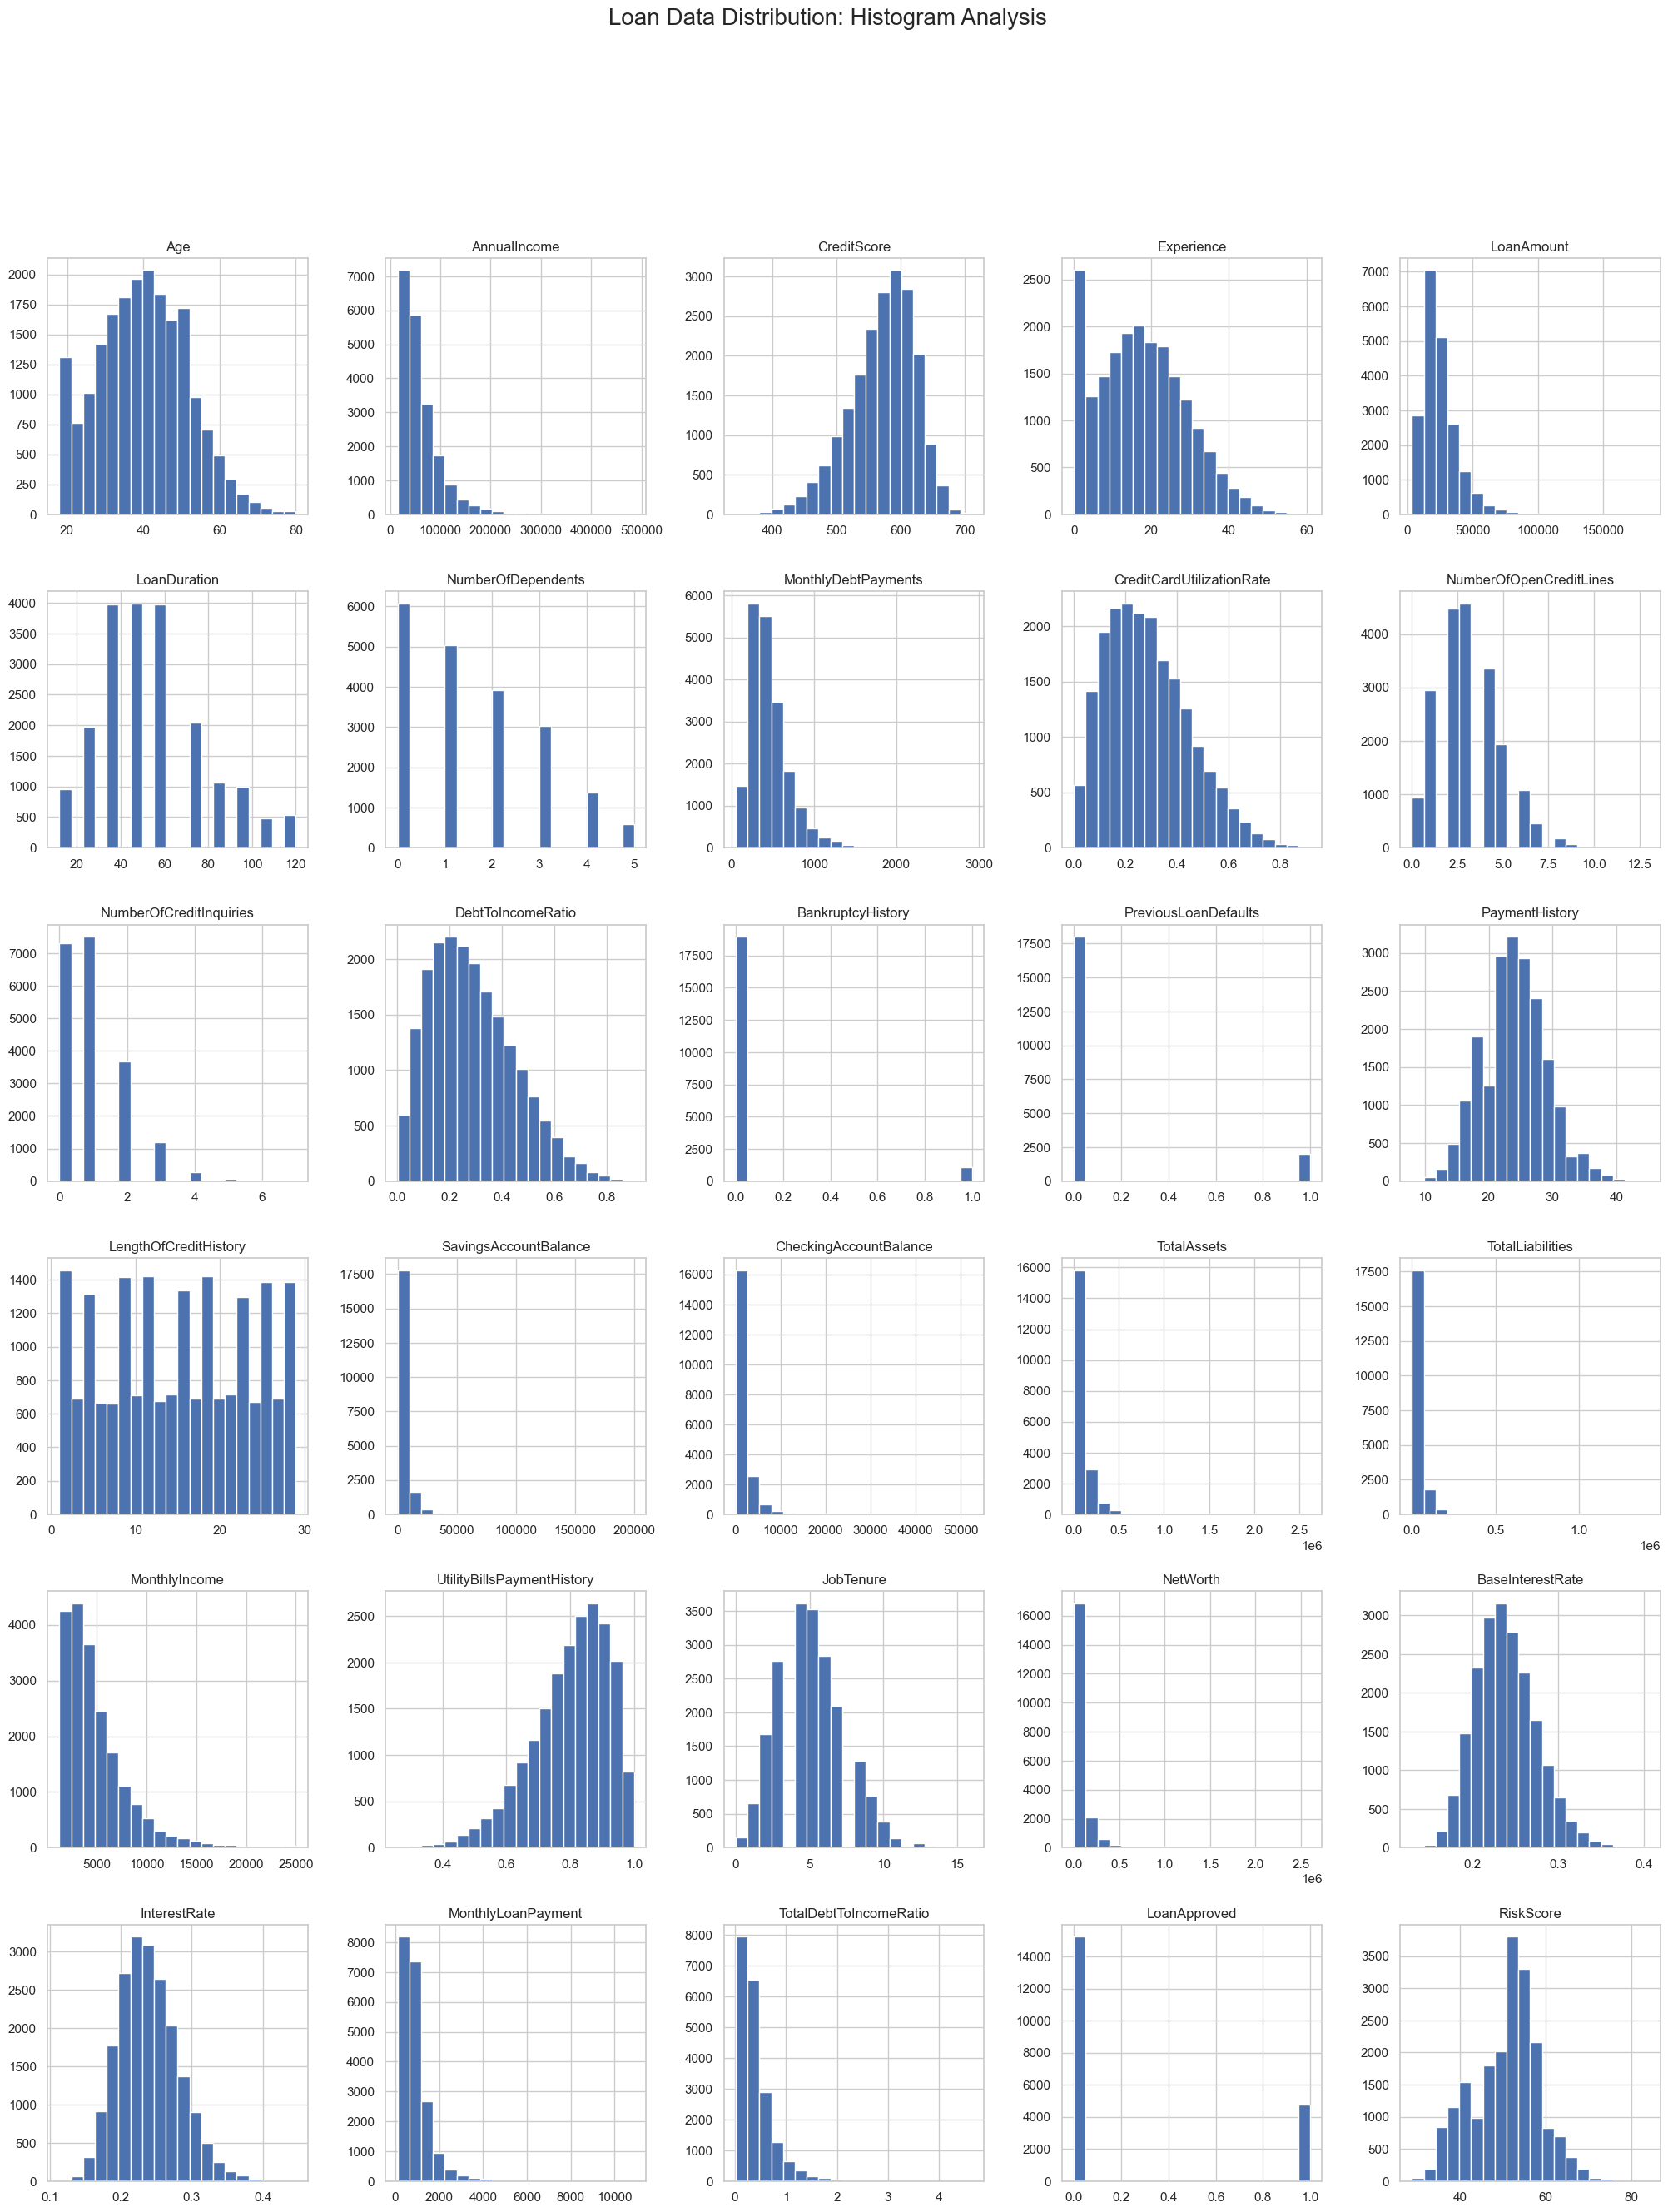

In [ ]:
df.hist(bins=20, figsize=(25,30))
plt.suptitle('Loan Data Distribution: Histogram Analysis', fontsize=20)
plt.show()

<Axes: >

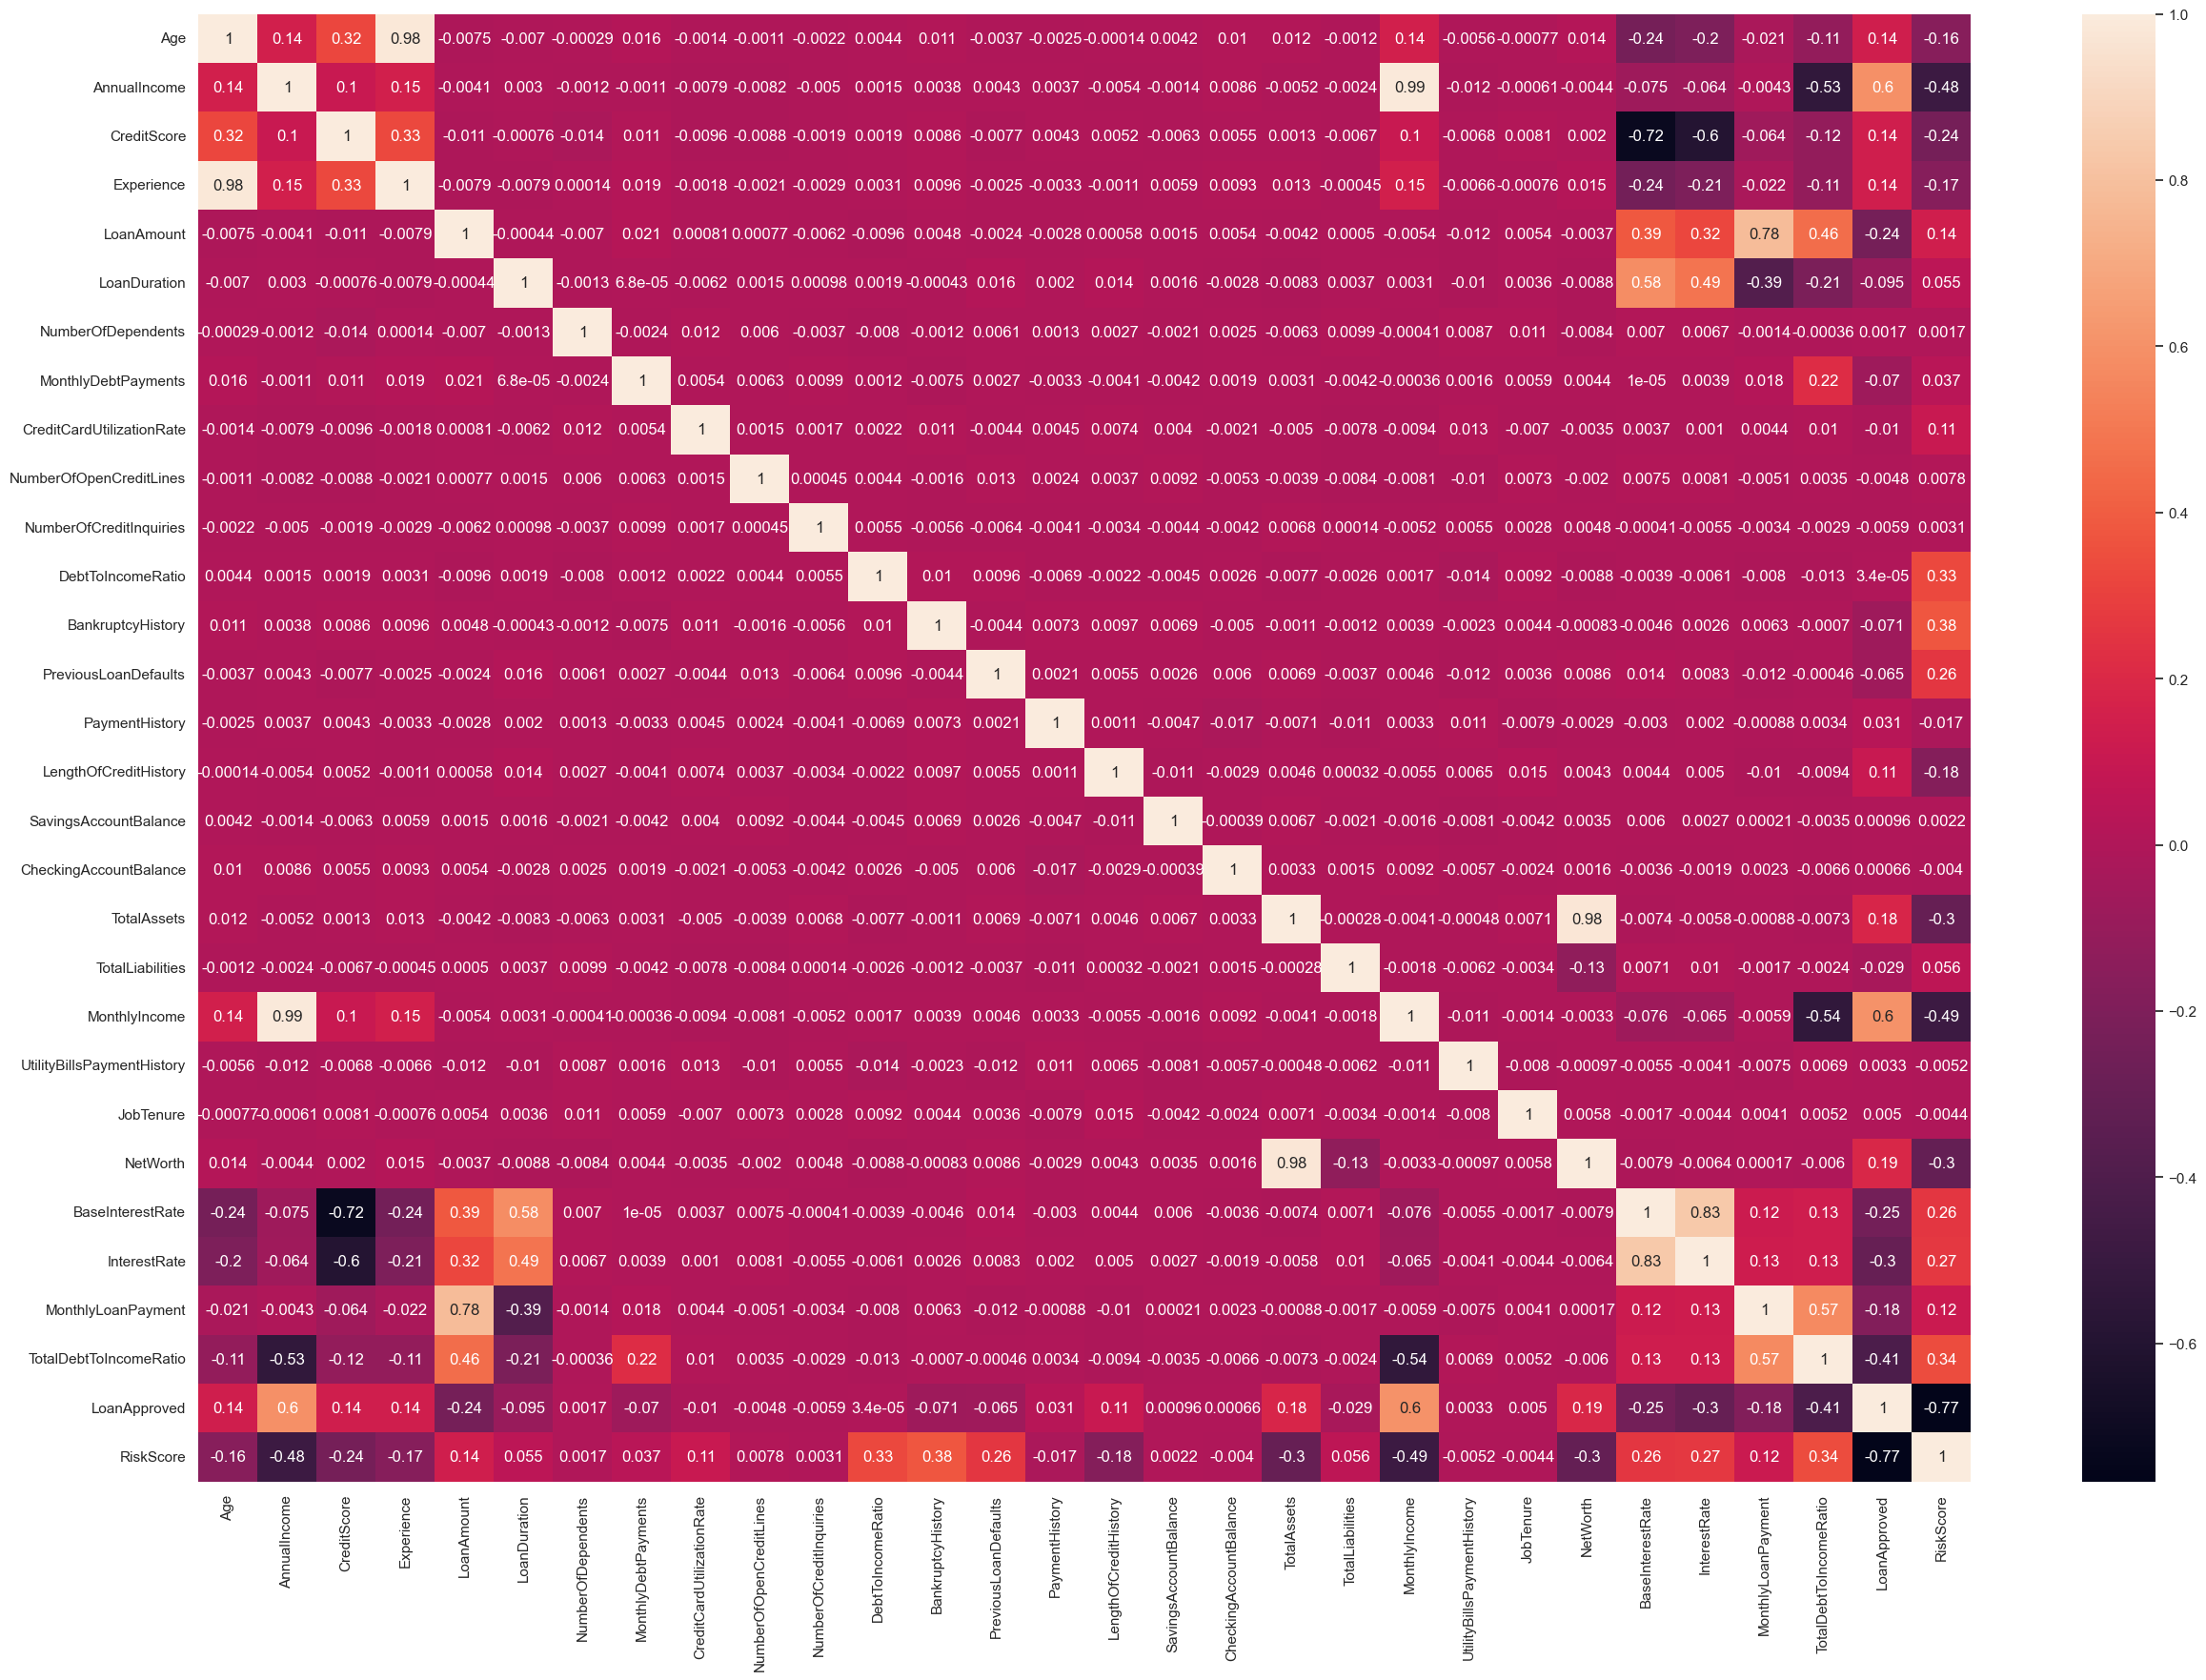

In [ ]:
plt.figure(figsize=(30, 20))
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True), annot=True)

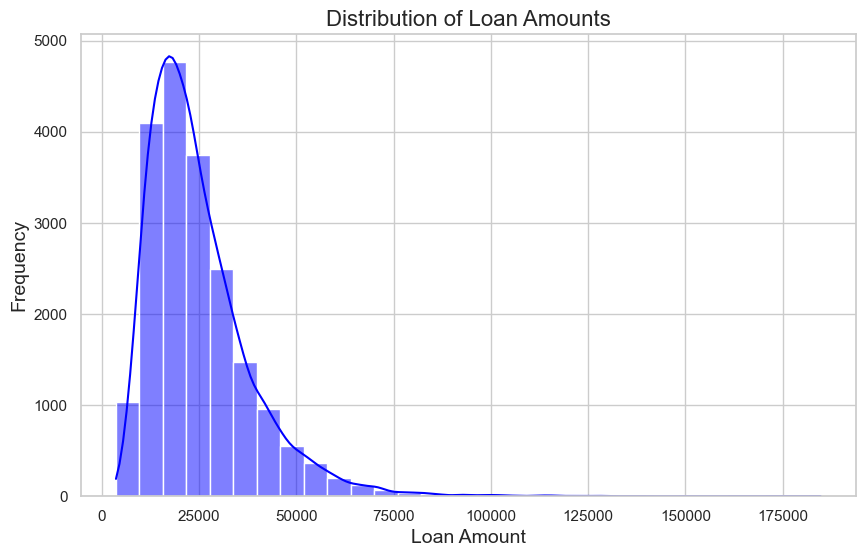

In [ ]:
# Plot 1: Distribution of Loan Amounts
plt.figure(figsize=(10, 6))
sns.histplot(df['LoanAmount'], kde=True, bins=30, color="blue")
plt.title("Distribution of Loan Amounts", fontsize=16)
plt.xlabel("Loan Amount", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.show()

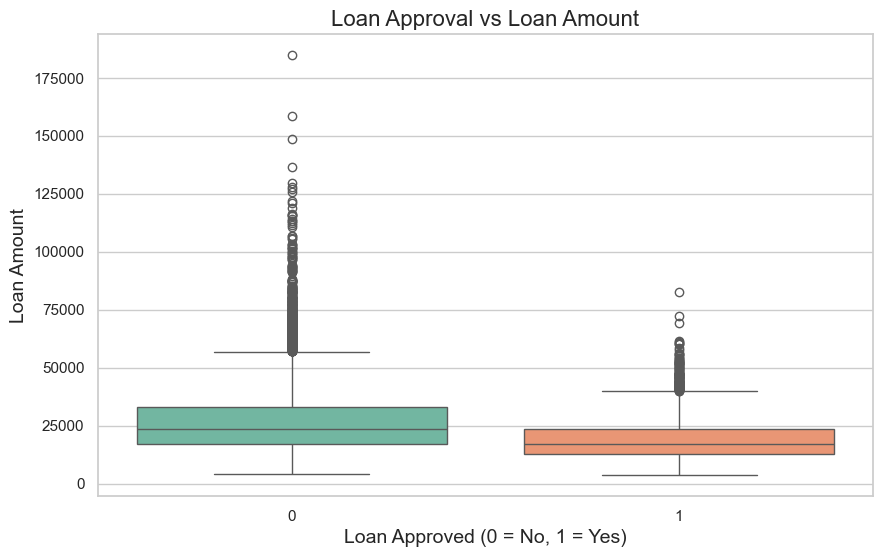

In [ ]:
# Plot 2: Loan Approval vs Loan Amount
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='LoanApproved', y='LoanAmount', palette="Set2")
plt.title("Loan Approval vs Loan Amount", fontsize=16)
plt.xlabel("Loan Approved (0 = No, 1 = Yes)", fontsize=14)
plt.ylabel("Loan Amount", fontsize=14)
plt.show()

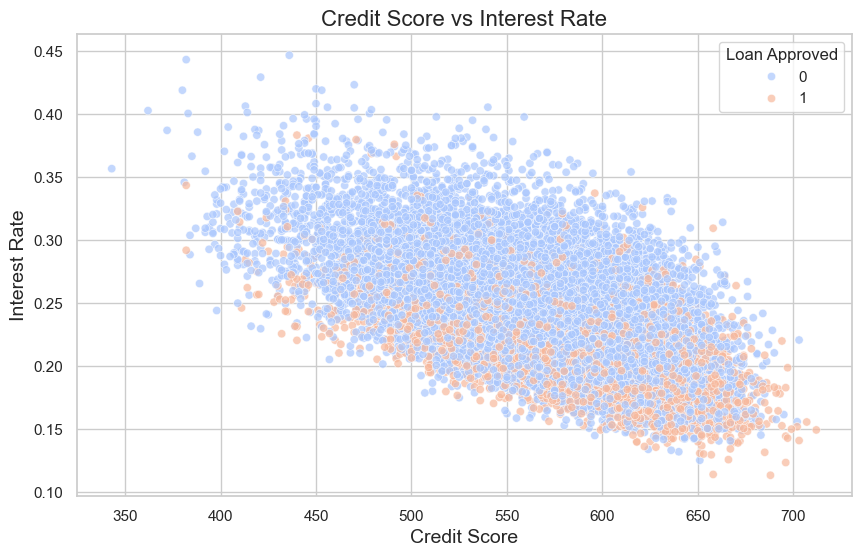

In [ ]:
# Plot 3: Credit Score vs Interest Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CreditScore', y='InterestRate', hue='LoanApproved', palette="coolwarm", alpha=0.7)
plt.title("Credit Score vs Interest Rate", fontsize=16)
plt.xlabel("Credit Score", fontsize=14)
plt.ylabel("Interest Rate", fontsize=14)
plt.legend(title="Loan Approved", loc="upper right")
plt.show()

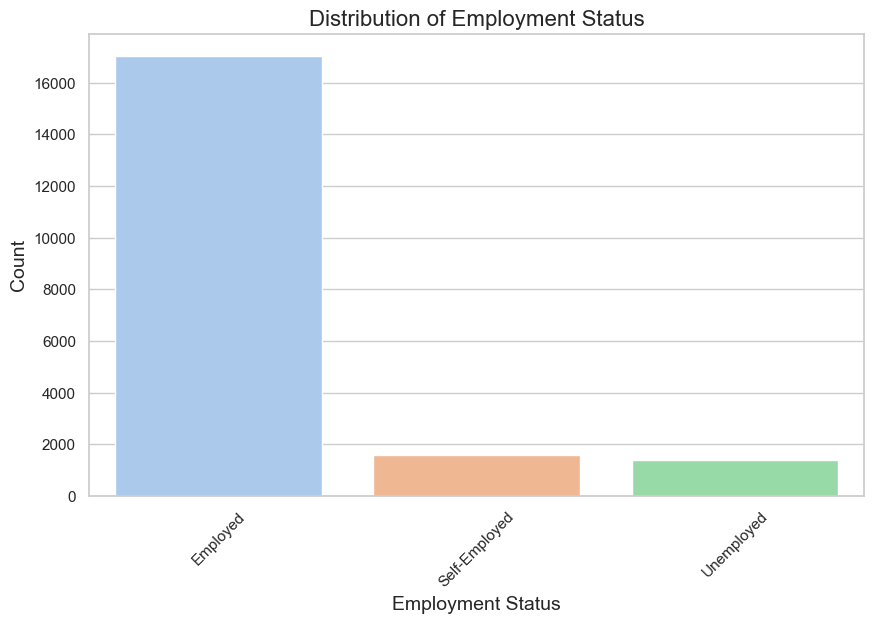

In [ ]:
# Plot 4: Employment Status Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='EmploymentStatus', palette="pastel")
plt.title("Distribution of Employment Status", fontsize=16)
plt.xlabel("Employment Status", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=45)
plt.show()

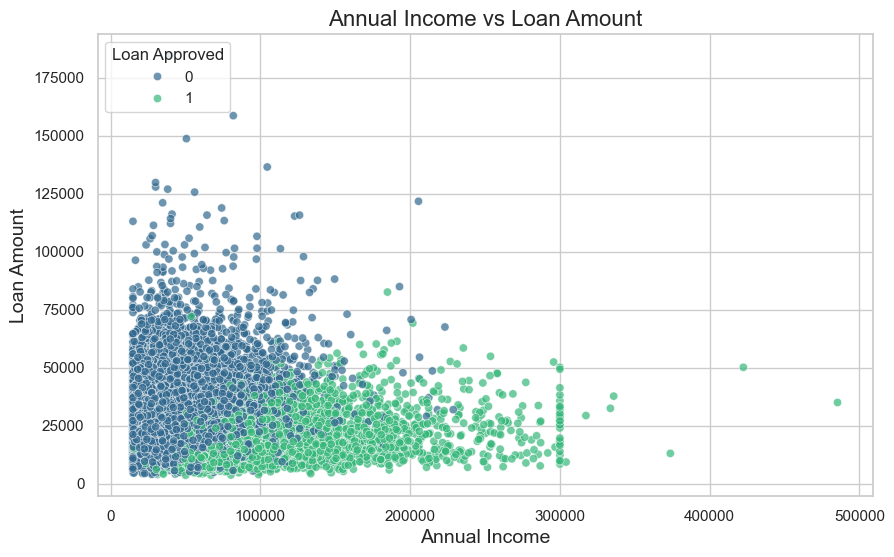

In [ ]:
# Plot 5: Annual Income vs Loan Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='AnnualIncome', y='LoanAmount', hue='LoanApproved', palette="viridis", alpha=0.7)
plt.title("Annual Income vs Loan Amount", fontsize=16)
plt.xlabel("Annual Income", fontsize=14)
plt.ylabel("Loan Amount", fontsize=14)
plt.legend(title="Loan Approved", loc="upper left")
plt.show()

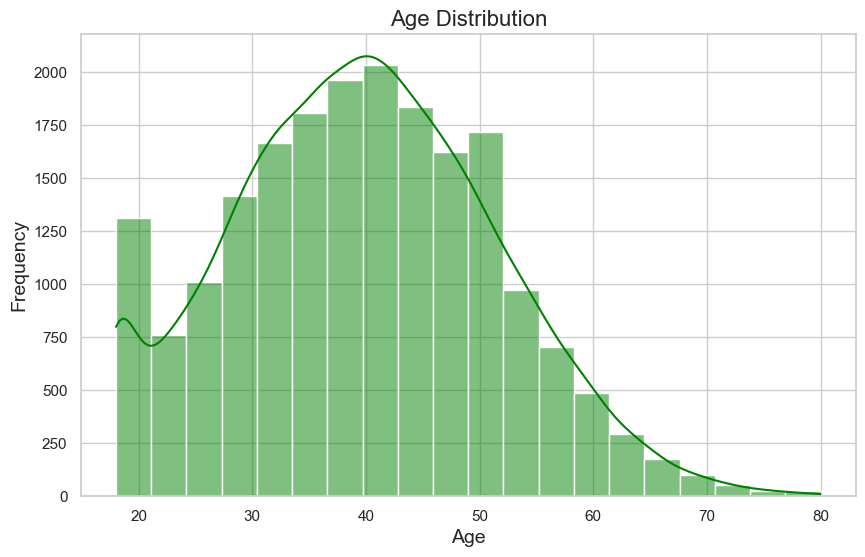

In [ ]:
# Plot 6: Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=20, color="green")
plt.title("Age Distribution", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.show()

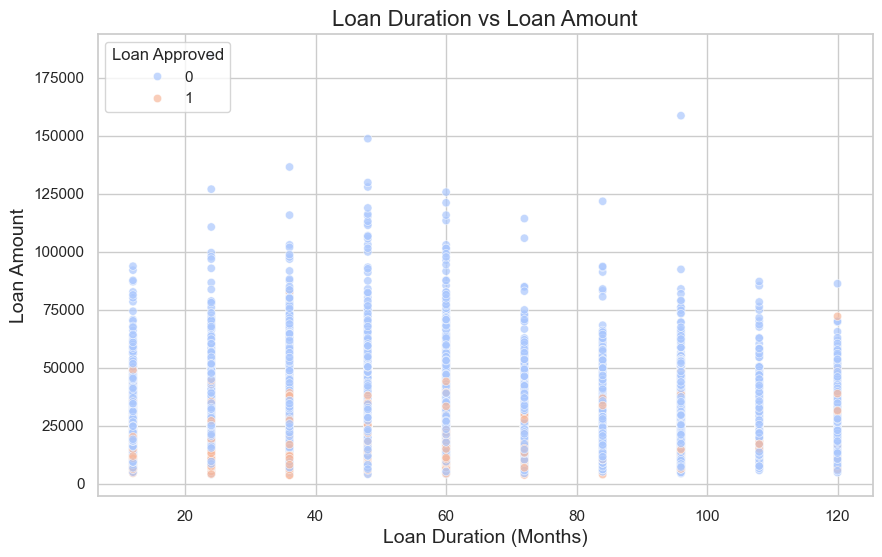

In [ ]:
# Plot 7: Loan Duration vs Loan Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='LoanDuration', y='LoanAmount', hue='LoanApproved', palette="coolwarm", alpha=0.7)
plt.title("Loan Duration vs Loan Amount", fontsize=16)
plt.xlabel("Loan Duration (Months)", fontsize=14)
plt.ylabel("Loan Amount", fontsize=14)
plt.legend(title="Loan Approved", loc="upper left")
plt.show()

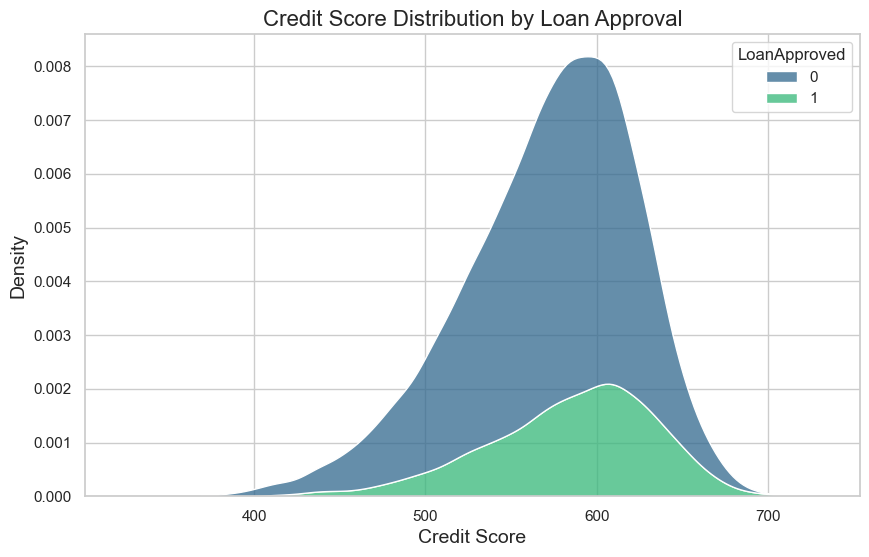

In [ ]:
# Plot 8: Credit Score Distribution by Loan Approval
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='CreditScore', hue='LoanApproved', multiple="stack", palette="viridis")
plt.title("Credit Score Distribution by Loan Approval", fontsize=16)
plt.xlabel("Credit Score", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.show()

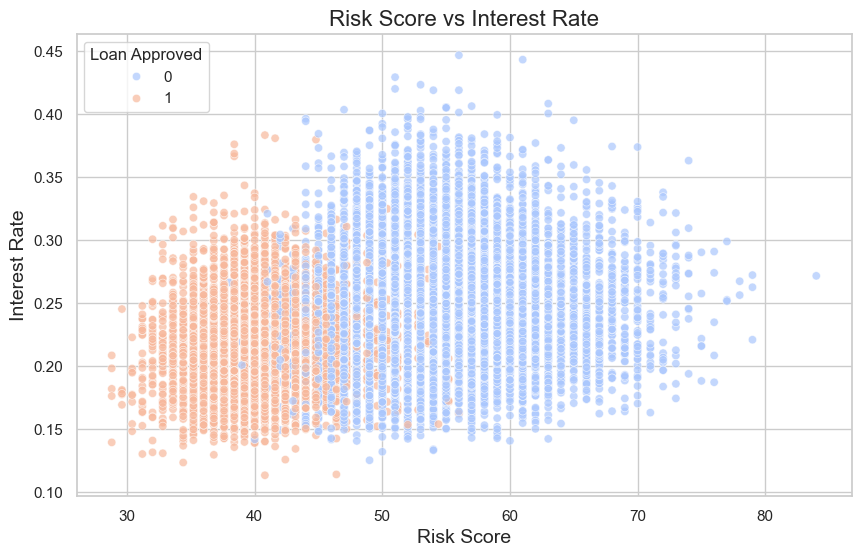

In [ ]:
# Plot 9: Risk Score vs Interest Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='RiskScore', y='InterestRate', hue='LoanApproved', palette="coolwarm", alpha=0.7)
plt.title("Risk Score vs Interest Rate", fontsize=16)
plt.xlabel("Risk Score", fontsize=14)
plt.ylabel("Interest Rate", fontsize=14)
plt.legend(title="Loan Approved", loc="upper left")
plt.show()

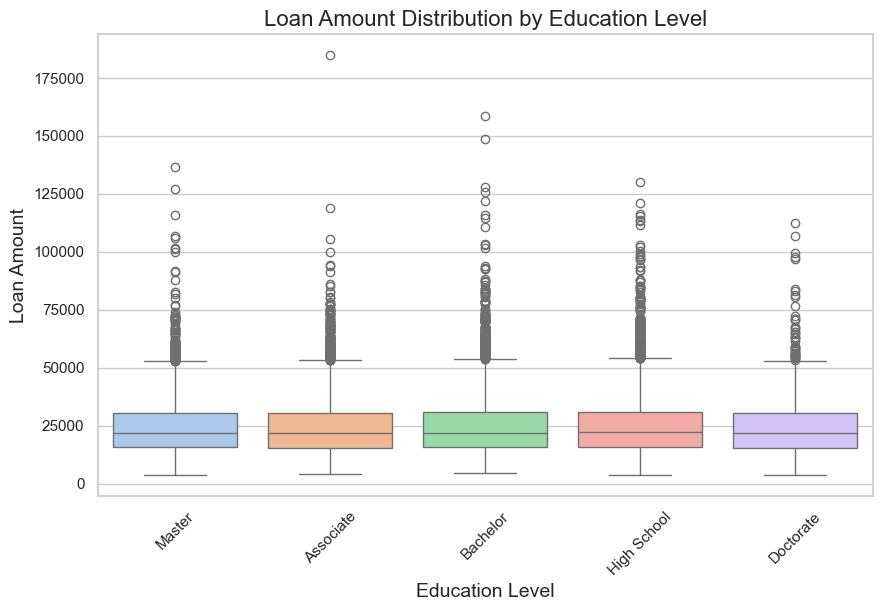

In [ ]:
# Plot 10: Loan Amount Distribution by Education Level
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='EducationLevel', y='LoanAmount', palette="pastel")
plt.title("Loan Amount Distribution by Education Level", fontsize=16)
plt.xlabel("Education Level", fontsize=14)
plt.ylabel("Loan Amount", fontsize=14)
plt.xticks(rotation=45)
plt.show()

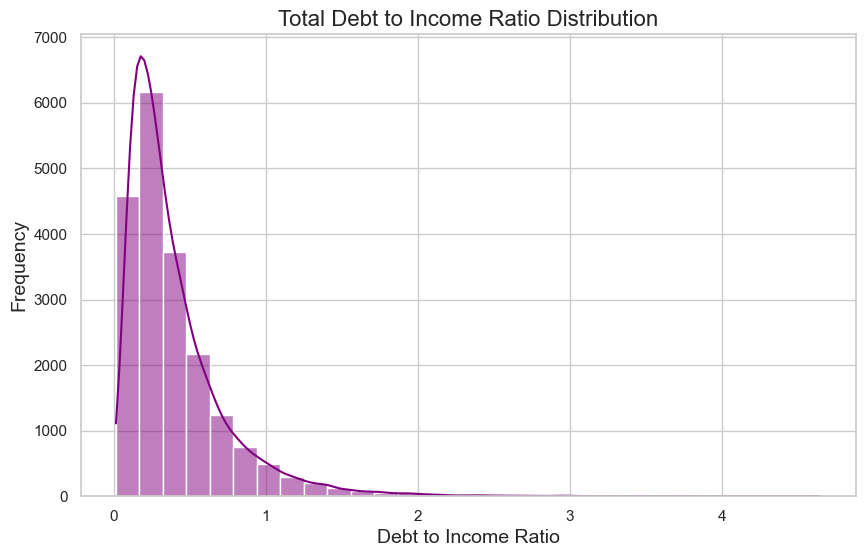

In [ ]:
# Plot 11: Total Debt to Income Ratio Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalDebtToIncomeRatio'], kde=True, bins=30, color="purple")
plt.title("Total Debt to Income Ratio Distribution", fontsize=16)
plt.xlabel("Debt to Income Ratio", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.show()

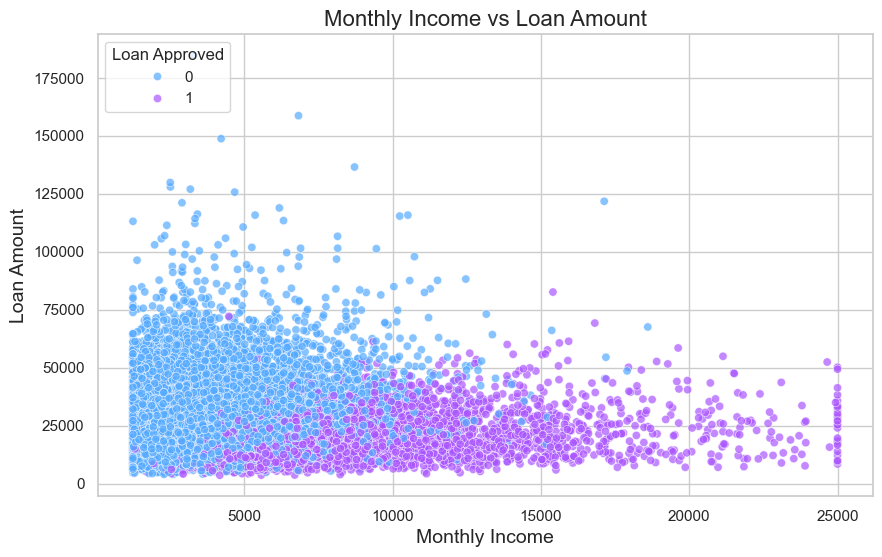

In [ ]:
# Plot 12: Monthly Income vs Loan Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='MonthlyIncome', y='LoanAmount', hue='LoanApproved', palette="cool", alpha=0.7)
plt.title("Monthly Income vs Loan Amount", fontsize=16)
plt.xlabel("Monthly Income", fontsize=14)
plt.ylabel("Loan Amount", fontsize=14)
plt.legend(title="Loan Approved", loc="upper left")
plt.show()

# Machine Learning Models

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier()
}

results = {
    'Model':[],
    'Accuracy': [],
    'AVG Cross Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

# Train models and collect metrics
for model_name, clf in models.items():
    print(f'Training {model_name}...')

    # Train on SMOTE-resampled data
    clf.fit(X_train_resampled, y_train_resampled)

    # Predict on test set
    y_pred = clf.predict(X_test)

    # Evaluate model
    accuracy = accuracy_score(y_test, y_pred)
    cross_accuracy = cross_val_score(clf, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Store results
    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy)
    results['AVG Cross Accuracy'].append(cross_accuracy.mean())
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1-Score'].append(f1)

    print(f'Training {model_name} COMPLETED')
    print('-------------------------------')

# Convert results to DataFrame
results_df = pd.DataFrame(results)

Training Decision Tree...
Training Decision Tree COMPLETED
-------------------------------
Training Random Forest...
Training Random Forest COMPLETED
-------------------------------
Training Logistic Regression...
Training Logistic Regression COMPLETED
-------------------------------
Training SVM...
Training SVM COMPLETED
-------------------------------
Training KNN...
Training KNN COMPLETED
-------------------------------


In [ ]:
results_df

,Model,Accuracy,AVG Cross Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.99175,0.991048,0.980229,0.985356,0.982786
1,Random Forest,0.99000,0.993389,0.975104,0.983264,0.979167
2,Logistic Regression,0.99950,0.999589,0.997912,1.000000,0.998955
3,SVM,0.99900,0.999507,0.998952,0.996862,0.997906
4,KNN,0.92400,0.944851,0.771215,0.969665,0.859129


In [ ]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Scale the data (optional but recommended for better model convergence)
scaler = StandardScaler()
X_train_transformed = scaler.fit_transform(X_train_resampled)  # Use SMOTE-resampled training data

# Perform logistic regression with statsmodels
logit_model = sm.Logit(y_train_resampled, X_train_transformed)  # Use resampled target variable
result = logit_model.fit(maxiter=100)  # Increase max iterations if necessary

# Display the model's summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.001606
         Iterations 18
                           Logit Regression Results                           
Dep. Variable:           LoanApproved   No. Observations:                24352
Model:                          Logit   Df Residuals:                    24318
Method:                           MLE   Df Model:                           33
Date:                Tue, 10 Dec 2024   Pseudo R-squ.:                  0.9977
Time:                        01:20:30   Log-Likelihood:                -39.104
converged:                       True   LL-Null:                       -16880.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1671      0.345      0.485      0.628      -0.509       0.843
x2            -0.3110      1

# ANN Model

In [ ]:
sns.set_style('whitegrid')

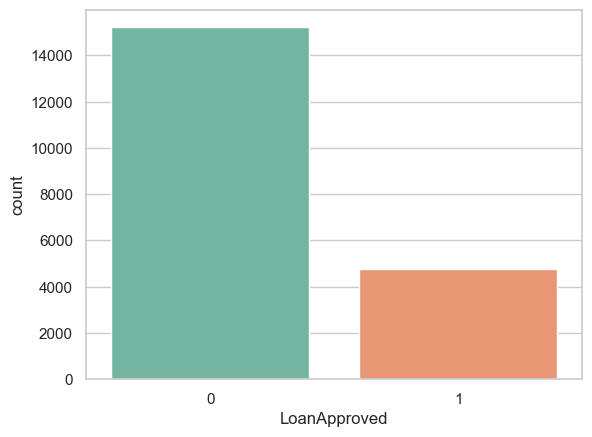

In [ ]:
sns.countplot(x=df['LoanApproved'],palette='Set2');

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [ ]:
model=Sequential()
model.add(Dense(10,activation='relu',kernel_initializer='he_normal',kernel_regularizer='l2'))

model.add(Dense(15,activation='tanh'))

model.add(Dense(10,activation='silu'))

model.add(Dense(7,activation='tanh'))

model.add(Dense(5,activation='elu'))

model.add(Dense(3,activation='relu'))


model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(x=X_train,y=y_train,epochs=10,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7922 - loss: 0.5604 - val_accuracy: 0.9965 - val_loss: 0.0728
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9966 - loss: 0.0607 - val_accuracy: 0.9998 - val_loss: 0.0331
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9990 - loss: 0.0302 - val_accuracy: 0.9998 - val_loss: 0.0201
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9992 - loss: 0.0189 - val_accuracy: 0.9998 - val_loss: 0.0135
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9989 - loss: 0.0148 - val_accuracy: 1.0000 - val_loss: 0.0121
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9996 - loss: 0.0124 - val_accuracy: 0.9987 - val_loss: 0.0129
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9992 - loss: 0.0113 - val_accuracy: 0.9998 - val_loss: 0.0084
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9994 - loss: 0.0098 - val_accuracy: 0.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (32, 10)                    │             360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 15)                    │             165 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (32, 10)                    │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (32, 7)                     │              77 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (32, 5)                     │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (32, 3)                     │              18 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (32, 1)                     │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,474 (9.67 KB)

 Trainable params: 824 (3.22 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,650 (6.45 KB)

<Axes: >

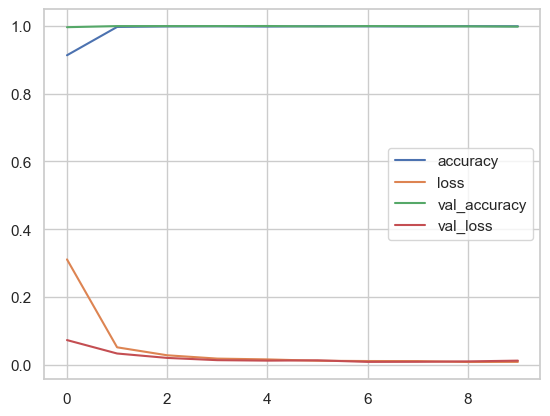

In [ ]:
Results=pd.DataFrame(model.history.history)
Results.plot()

<Axes: >

<Figure size 1200x600 with 0 Axes>

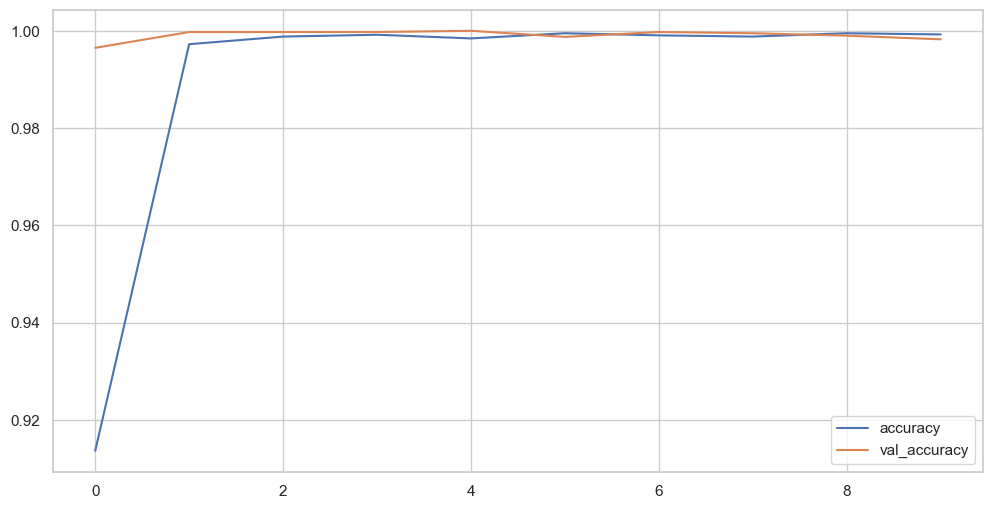

In [ ]:
plt.figure(figsize=(12,6))
Results[['accuracy','val_accuracy']].plot(figsize=(12,6))

<Axes: >

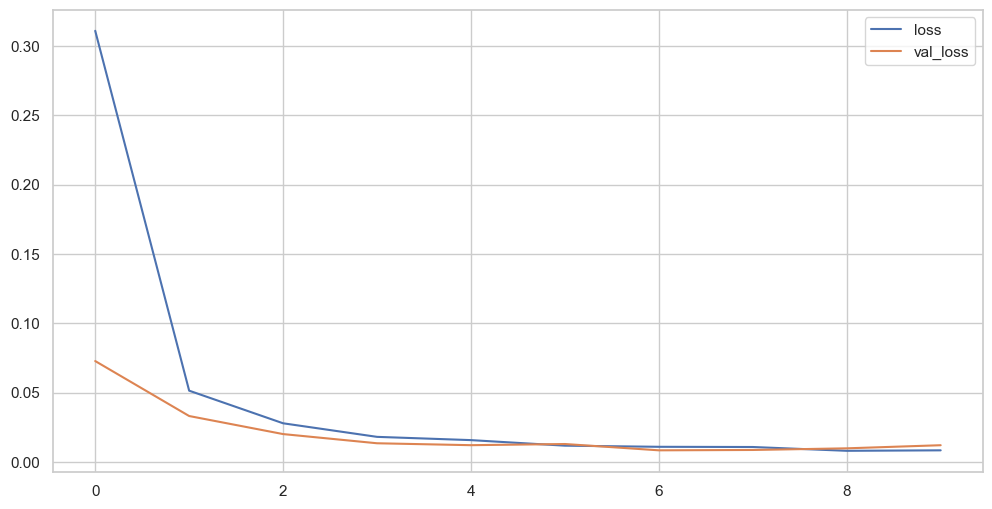

In [ ]:
Results[['loss','val_loss']].plot(figsize=(12,6))

In [ ]:
model.evaluate(x=X_test,y=y_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9956 - loss: 0.0175


[0.012067343108355999, 0.9982500076293945]

In [ ]:
predictions=(model.predict(X_test) >0.5).astype('int32')
predictions

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step


array([[0],
       [0],
       [1],
       ...,
       [1],
       [0],
       [0]])

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3044
           1       1.00      1.00      1.00       956

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



<Axes: >

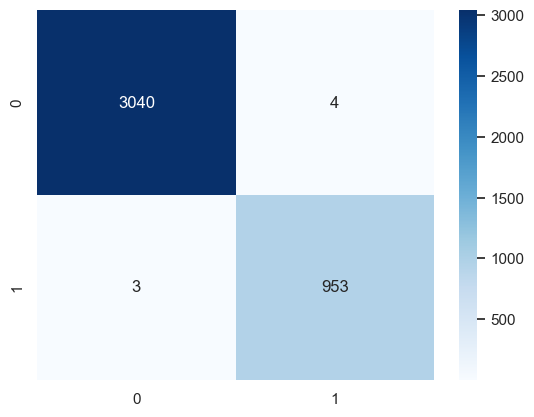

In [ ]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, cmap='Blues', annot=True, fmt='.0f')